Merged DataFrame:
        Country  Aspect_Ratio Dominant_Color  Sentiment_Score  \
0        Brazil          1.50          Green             0.15   
1         Japan          1.50            Red             0.05   
2  South Africa          1.33            Red             0.20   
3         India          1.50        Saffron             0.10   
4        Mexico          1.50            Red             0.00   

   Avg_Word_Length  Tempo  Duration  
0              4.2    120        60  
1              4.0    115        55  
2              4.3    125        70  
3              4.1    130        65  
4              4.0    110        60  
Correlation Matrix:
                 Aspect_Ratio  Sentiment_Score  Avg_Word_Length     Tempo  \
Aspect_Ratio         1.000000        -0.707107        -0.771744 -0.353553   
Sentiment_Score     -0.707107         1.000000         0.970143  0.700000   
Avg_Word_Length     -0.771744         0.970143         1.000000  0.606339   
Tempo               -0.353553      

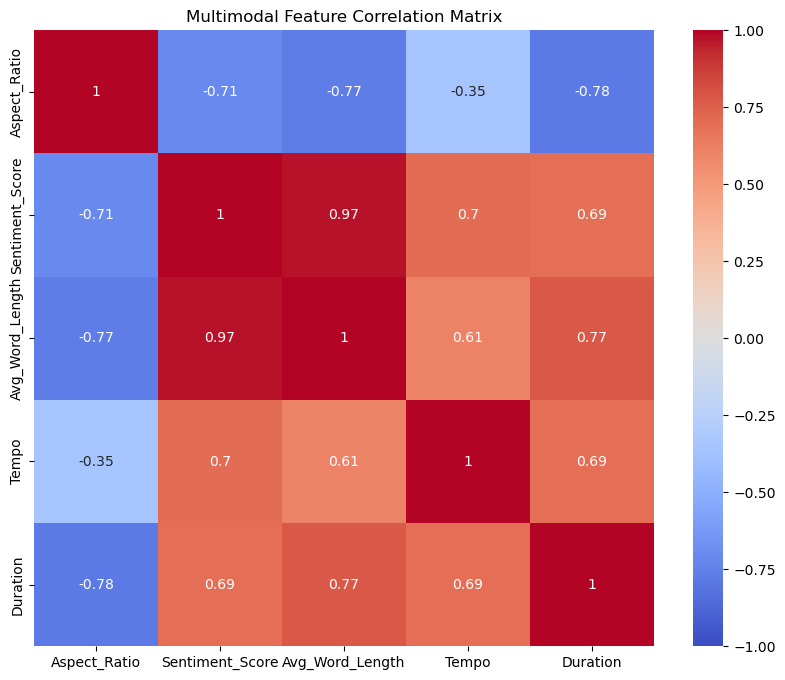

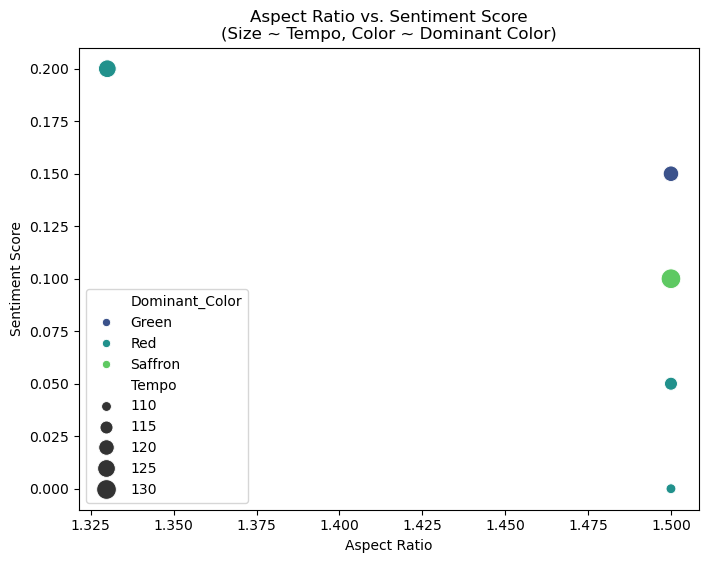

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Define dataframes for each modality
flag_df = pd.DataFrame({
    'Country': ['Brazil', 'Japan', 'South Africa', 'India', 'Mexico'],
    'Aspect_Ratio': [1.5, 1.5, 1.33, 1.5, 1.5],
    'Dominant_Color': ['Green', 'Red', 'Red', 'Saffron', 'Red']  # Example colors
})

text_df = pd.DataFrame({
    'Country': ['Brazil', 'Japan', 'South Africa', 'India', 'Mexico'],
    'Sentiment_Score': [0.15, 0.05, 0.2, 0.1, 0.0],  # Sample sentiment values
    'Avg_Word_Length': [4.2, 4.0, 4.3, 4.1, 4.0]
})

audio_df = pd.DataFrame({
    'Country': ['Brazil', 'Japan', 'South Africa', 'India', 'Mexico'],
    'Tempo': [120, 115, 125, 130, 110],  # BPM
    'Duration': [60, 55, 70, 65, 60]       # seconds
})

# Merge dataframes
merged_df = flag_df.merge(text_df, on='Country').merge(audio_df, on='Country')
print("Merged DataFrame:")
print(merged_df)

# Compute correlations
corr_matrix = merged_df.drop(columns=['Country', 'Dominant_Color']).corr()
print("Correlation Matrix:")
print(corr_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Multimodal Feature Correlation Matrix")
plt.show()

# Scatter plot: Explore relationship between Dominant Color (from flags) and Sentiment Score (from text)
# Since 'Dominant_Color' is categorical, we'll use a different approach
plt.figure(figsize=(8,6))
sns.scatterplot(data=merged_df, x='Aspect_Ratio', y='Sentiment_Score', 
                size='Tempo', hue='Dominant_Color', palette='viridis', sizes=(50,200))
plt.title("Aspect Ratio vs. Sentiment Score\n(Size ~ Tempo, Color ~ Dominant Color)")
plt.xlabel("Aspect Ratio")
plt.ylabel("Sentiment Score")
plt.legend()
plt.show()

